# Example FFT NUFFT Surface

Canonical transform notebook for DFT and NUFFT production surfaces.

## Scope

This notebook is the canonical example surface for `example_fft_nufft_surface`. It runs against the repo source tree through `/src`, shows direct public API usage, summarizes validation and benchmark status, and includes visual summaries.

In [1]:
import io
import json
import os
import re
import subprocess
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'arbplusjax').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)

PYTHON = os.getenv('ARBPLUSJAX_PYTHON', sys.executable)
JAX_MODE = os.getenv('JAX_MODE', 'cpu').strip().lower()
JAX_DTYPE = os.getenv('JAX_DTYPE', 'float64').strip().lower()
RUN_ENV = os.environ.copy()
RUN_ENV['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + RUN_ENV.get('PYTHONPATH', '')
if JAX_MODE == 'cpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cpu'
elif JAX_MODE == 'gpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cuda'
RUN_ENV['JAX_ENABLE_X64'] = '1' if JAX_DTYPE == 'float64' else '0'
EXAMPLE_INPUT_ROOT = REPO_ROOT / 'examples' / 'inputs' / 'example_fft_nufft_surface'
EXAMPLE_OUTPUT_ROOT = REPO_ROOT / 'examples' / 'outputs' / 'example_fft_nufft_surface'
EXAMPLE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def run(cmd: list[str], *, capture: bool = False):
    print('[cmd]', ' '.join(cmd))
    return subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=capture, check=True)


## Environment

The notebook reports interpreter, selected JAX mode, and the active backend/device view. Canonical retained execution in this repo state is CPU-oriented, but the notebook calling pattern remains CPU/GPU portable and explicitly parameterized for `float32` and `float64`.

In [2]:
SUPPORTED_JAX_MODES = ('cpu', 'gpu')
SUPPORTED_JAX_DTYPES = ('float32', 'float64')
if JAX_MODE not in SUPPORTED_JAX_MODES:
    raise ValueError(f'Unsupported JAX_MODE: {JAX_MODE}')
if JAX_DTYPE not in SUPPORTED_JAX_DTYPES:
    raise ValueError(f'Unsupported JAX_DTYPE: {JAX_DTYPE}')
print('python:', PYTHON)
print('jax_mode:', JAX_MODE)
print('jax_dtype:', JAX_DTYPE)
print('supported_jax_modes:', SUPPORTED_JAX_MODES)
print('supported_jax_dtypes:', SUPPORTED_JAX_DTYPES)
print('validation_slice:', 'cpu_current__gpu_portable_contract')
runtime = run([PYTHON, 'tools/check_jax_runtime.py'], capture=True)
print(runtime.stdout)
runtime_payload = json.loads(runtime.stdout)
(EXAMPLE_OUTPUT_ROOT / f'runtime_{JAX_MODE}.json').write_text(json.dumps(runtime_payload, indent=2) + '\n', encoding='utf-8')

python: /home/phili/miniforge3/envs/jax/bin/python
jax_mode: cpu
jax_dtype: float64
supported_jax_modes: ('cpu', 'gpu')
supported_jax_dtypes: ('float32', 'float64')
validation_slice: cpu_current__gpu_portable_contract
[cmd] /home/phili/miniforge3/envs/jax/bin/python tools/check_jax_runtime.py


{
  "platform": "cpu",
  "devices": [
    "TFRT_CPU_0"
  ],
  "jax_enable_x64": true,
  "env": {
    "JAX_PLATFORM_NAME": "",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "",
    "XLA_PYTHON_CLIENT_MEM_FRACTION": "",
    "XLA_FLAGS": ""
  }
}



235

## Direct Usage

Exercise direct DFT and cached NUFFT paths on representative complex inputs.

In [3]:
import jax.numpy as jnp
from arbplusjax import dft, nufft

x = jnp.asarray([1.0 + 0.0j, 0.5 + 0.25j, -0.75 + 0.1j, 0.25 - 0.5j], dtype=jnp.complex128)
points = jnp.asarray([0.1, 0.25, 0.55, 0.8], dtype=jnp.float64)
values = jnp.asarray([1.0 + 0.1j, 0.5 - 0.2j, -0.25 + 0.4j, 0.75 + 0.0j], dtype=jnp.complex128)
plan = nufft.nufft_type1_cached_prepare(points, 8, method='lanczos')
transform_results = {
    'dft': dft.dft_jit(x),
    'nufft_type1': nufft.nufft_type1(points, values, 8, method='lanczos'),
    'nufft_type1_cached': nufft.nufft_type1_cached_apply_jit(plan, values),
}
display(transform_results)

{'dft': Array([ 1. -0.15j,  2.5-0.35j, -0.5+0.35j,  1. +0.15j], dtype=complex128),
 'nufft_type1': Array([ 2.        +0.3j       ,  1.01310673-0.75186758j,
        -0.6694518 +0.19096631j, -0.79599363-1.35870186j,
         0.28466017-1.22053533j, -0.85001298-0.84889384j,
        -0.67866894+1.53303175j, -1.27928285+1.89201122j],      dtype=complex128),
 'nufft_type1_cached': Array([ 2.        +0.3j       ,  1.01310673-0.75186758j,
        -0.6694518 +0.19096631j, -0.79599363-1.35870186j,
         0.28466017-1.22053533j, -0.85001298-0.84889384j,
        -0.67866894+1.53303175j, -1.27928285+1.89201122j],      dtype=complex128)}

## Production Pattern

Transform workloads should cache NUFFT plans and reuse them across repeated calls. Keep method choice and output grid size fixed inside a service path; avoid switching between direct and Lanczos or changing mode counts request-to-request unless you expect recompiles.

In [4]:
cached_type1 = nufft.nufft_type1_cached_prepare(points, 8, method='lanczos')
transform_service = {
    'dft_repeat': dft.dft_jit(x),
    'nufft_cached_repeat': nufft.nufft_type1_cached_apply_jit(cached_type1, values),
}
display(transform_service)

{'dft_repeat': Array([ 1. -0.15j,  2.5-0.35j, -0.5+0.35j,  1. +0.15j], dtype=complex128),
 'nufft_cached_repeat': Array([ 2.        +0.3j       ,  1.01310673-0.75186758j,
        -0.6694518 +0.19096631j, -0.79599363-1.35870186j,
         0.28466017-1.22053533j, -0.85001298-0.84889384j,
        -0.67866894+1.53303175j, -1.27928285+1.89201122j],      dtype=complex128)}

## Extending Benchmarks

To extend transform benchmarks, add the new DFT/NUFFT case in `benchmark_fft_nufft.py` with a stable `name` field so the CSV-style summary in this notebook remains compatible.

## Fast JAX Point Pattern

Transforms already have explicit compiled kernels. For fast JAX usage, keep the plan cached and compare the compiled repeated path against the direct result.

In [5]:
fast_transform = nufft.nufft_type1_cached_apply_jit(plan, values)
direct_transform = nufft.nufft_type1(points, values, 8, method='lanczos')
display({'jit_shape': fast_transform.shape, 'jit_matches_direct': bool(jnp.allclose(fast_transform, direct_transform, rtol=1e-6, atol=1e-6))})

{'jit_shape': (8,), 'jit_matches_direct': True}

## AD Product Pattern

Transform AD should be shown through a realistic loss on transform outputs rather than isolated scalar identities. This section differentiates a NUFFT energy objective and plots primal versus gradient over a scale sweep.

,scale,primal,grad
0,0.500000,4.921733,19.686930
1,0.543478,5.814901,21.398837
2,0.586957,6.782501,23.110744
3,0.630435,7.824531,24.822651
4,0.673913,8.940992,26.534558


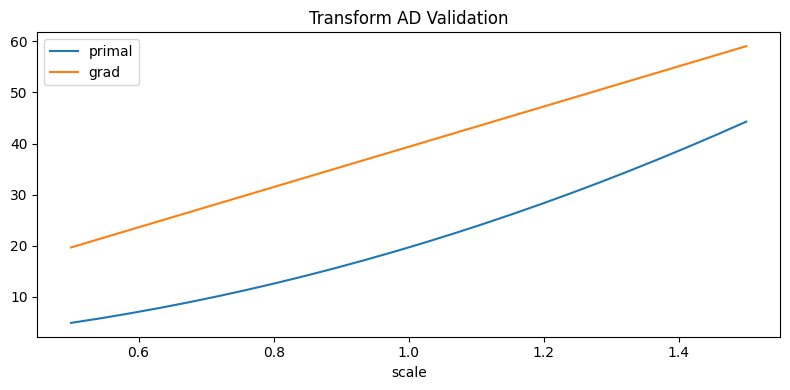

In [6]:
import jax
base_values = values
def transform_loss(scale):
    scaled = scale * base_values
    out = nufft.nufft_type1_cached_apply_jit(plan, scaled)
    return jnp.real(jnp.vdot(out, out))
scale_sweep = jnp.linspace(0.5, 1.5, 24, dtype=jnp.float64)
primal_vals = jax.vmap(transform_loss)(scale_sweep)
grad_vals = jax.vmap(jax.grad(transform_loss))(scale_sweep)
ad_df = pd.DataFrame({'scale': np.asarray(scale_sweep), 'primal': np.asarray(primal_vals), 'grad': np.asarray(grad_vals)})
display(ad_df.head())
ax = ad_df.plot(x='scale', y=['primal', 'grad'], figsize=(8, 4), title='Transform AD Validation')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Validation Summary

Run the DFT and NUFFT owner tests.

In [7]:
tests = run([
    PYTHON, '-m', 'pytest', '-q',
    'tests/test_dft_chassis.py',
    'tests/test_nufft.py',
    'tests/test_dft_parity.py',
], capture=True)
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
(EXAMPLE_OUTPUT_ROOT / f'pytest_{JAX_MODE}.txt').write_text(tests.stdout + ('\n' + tests.stderr if tests.stderr else ''), encoding='utf-8')

[cmd] /home/phili/miniforge3/envs/jax/bin/python -m pytest -q tests/test_dft_chassis.py tests/test_nufft.py tests/test_dft_parity.py


............................                                             [100%]
28 passed, 1 skipped in 25.73s



111

## Benchmark Summary

Run the transform benchmark and parse the emitted CSV.

In [8]:
completed = run([PYTHON, 'benchmarks/benchmark_fft_nufft.py'], capture=True)
print(completed.stdout)
bench_df = pd.read_csv(io.StringIO(completed.stdout))
bench_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'fft_nufft_benchmark_summary_{JAX_MODE}.csv', index=False)
display(bench_df.head(20))

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_fft_nufft.py


name,time_s
dft_power2_s,0.000040
dft_prime_bluestein_s,0.000056
dft_prime_precomp_s,0.000052
dft_prime_cached_point_s,0.000048
dft_prime_cached_basic_s,0.002078
dft_prime_batch_point_s,0.000159
dft_prime_cached_batch_point_s,0.000136
dft_prime_batch_basic_s,0.001207
dft_prime_cached_batch_basic_s,0.001227
dft2_s,0.000222
dft3_s,0.000306
acb_dft_prime_point_s,0.001782
nufft_type1_direct_s,0.001474
nufft_type1_lanczos_s,0.003714
nufft_type2_lanczos_s,0.005062
nufft_type1_cached_lanczos_s,0.000186
nufft_type2_cached_lanczos_s,0.000162
nufft_type1_cached_batch_s,0.000372
nufft_type1_2d_lanczos_s,0.007394
nufft_type2_2d_lanczos_s,0.004529
nufft_type1_3d_lanczos_s,0.011420
nufft_type2_3d_lanczos_s,0.007231



,name,time_s
0,dft_power2_s,0.000040
1,dft_prime_bluestein_s,0.000056
2,dft_prime_precomp_s,0.000052
3,dft_prime_cached_point_s,0.000048
4,dft_prime_cached_basic_s,0.002078
5,dft_prime_batch_point_s,0.000159
6,dft_prime_cached_batch_point_s,0.000136
7,dft_prime_batch_basic_s,0.001207
8,dft_prime_cached_batch_basic_s,0.001227
9,dft2_s,0.000222


## Plots

Plot the fastest transform cases.

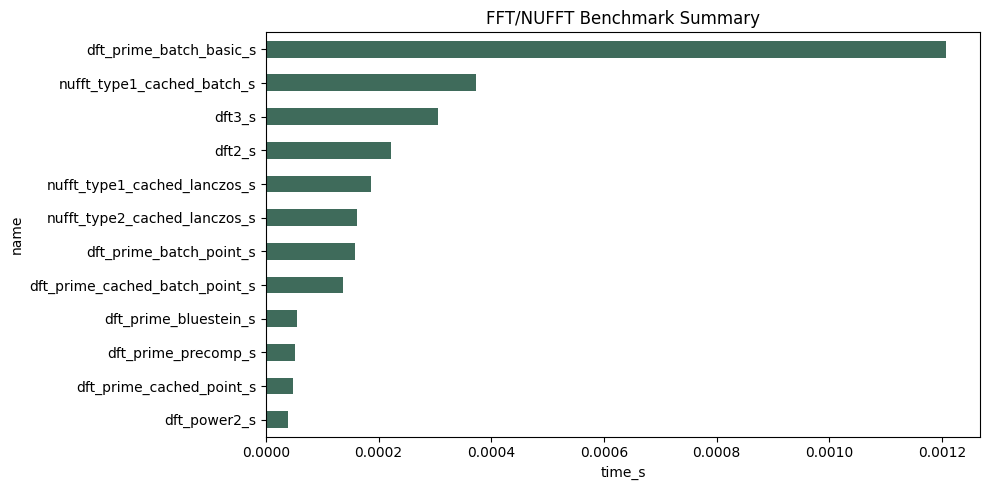

In [9]:
top = bench_df.sort_values('time_s').head(12)
ax = top.plot(x='name', y='time_s', kind='barh', figsize=(10, 5), color='#3f6b5b', legend=False, title='FFT/NUFFT Benchmark Summary')
ax.set_xlabel('time_s')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'fft_nufft_benchmark_summary_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Optional Diagnostics

GPU-focused runs remain optional and depend on the installed JAX runtime.

In [10]:
summary_lines = [
    f'# Example FFT NUFFT Surface Summary ({JAX_MODE})',
    '',
    f'- backend: `{runtime_payload["platform"]}`',
    f'- benchmark_rows: `{len(bench_df)}`',
    '',
    '## Fastest Metrics',
    '',
]
for row in top.to_dict(orient='records'):
    summary_lines.append(f"- `{row['name']}`: {row['time_s']:.6g}s")
(EXAMPLE_OUTPUT_ROOT / f'summary_{JAX_MODE}.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
display('\n'.join(summary_lines[:12]))

'# Example FFT NUFFT Surface Summary (cpu)\n\n- backend: `cpu`\n- benchmark_rows: `22`\n\n## Fastest Metrics\n\n- `dft_power2_s`: 4e-05s\n- `dft_prime_cached_point_s`: 4.8e-05s\n- `dft_prime_precomp_s`: 5.2e-05s\n- `dft_prime_bluestein_s`: 5.6e-05s\n- `dft_prime_cached_batch_point_s`: 0.000136s'